In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/nvidia-nemotron-model-reasoning-challenge/train.csv
/kaggle/input/competitions/nvidia-nemotron-model-reasoning-challenge/test.csv
/kaggle/input/models/huikang/nemotron-adapter/transformers/default/20/adapter_model.safetensors
/kaggle/input/models/huikang/nemotron-adapter/transformers/default/20/adapter_config.json
/kaggle/input/models/huikang/nemotron-adapter/transformers/default/20/README.md
/kaggle/input/models/huikang/nemotron-adapter/transformers/default/20/checkpoint_complete
/kaggle/input/models/kienngx/nemotron-nano-30b-trained/transformers/1800s-lora-rank32-false/1/adapter_model.safetensors
/kaggle/input/models/kienngx/nemotron-nano-30b-trained/transformers/1800s-lora-rank32-false/1/adapter_config.json
/kaggle/input/models/kienngx/nemotron-nano-30b-trained/transformers/1800s-lora-rank32-false/1/README.md
/kaggle/input/models/kienngx/nemotron-nano-30b-trained/transformers/1800s-lora-rank32-false/1/tokenizer.json
/kaggle/input/models/kienngx/nemotron-na

Using Python 3.12.12 environment at: /usr
   Updating https://github.com/thinking-machines-lab/tinker-cookbook.git (nightl
   Updating https://github.com/thinking-machines-lab/tinker-cookbook.git (nightl
   Updating https://github.com/thinking-machines-lab/tinker-cookbook.git (nightl
   Updating https://github.com/thinking-machines-lab/tinker-cookbook.git (nightl
   Updating https://github.com/thinking-machines-lab/tinker-cookbook.git (nightl
   Updating https://github.com/thinking-machines-lab/tinker-cookbook.git (nightl
   Updating https://github.com/thinking-machines-lab/tinker-cookbook.git (nightl
   Updating https://github.com/thinking-machines-lab/tinker-cookbook.git (nightl
   Updating https://github.com/thinking-machines-lab/tinker-cookbook.git (nightl
   Updating https://github.com/thinking-machines-lab/tinker-cookbook.git (nightl
   Updating https://github.com/thinking-machines-lab/tinker-cookbook.git (nightl
    Updated https://github.com/thinking-machines-lab/tinker-cookboo

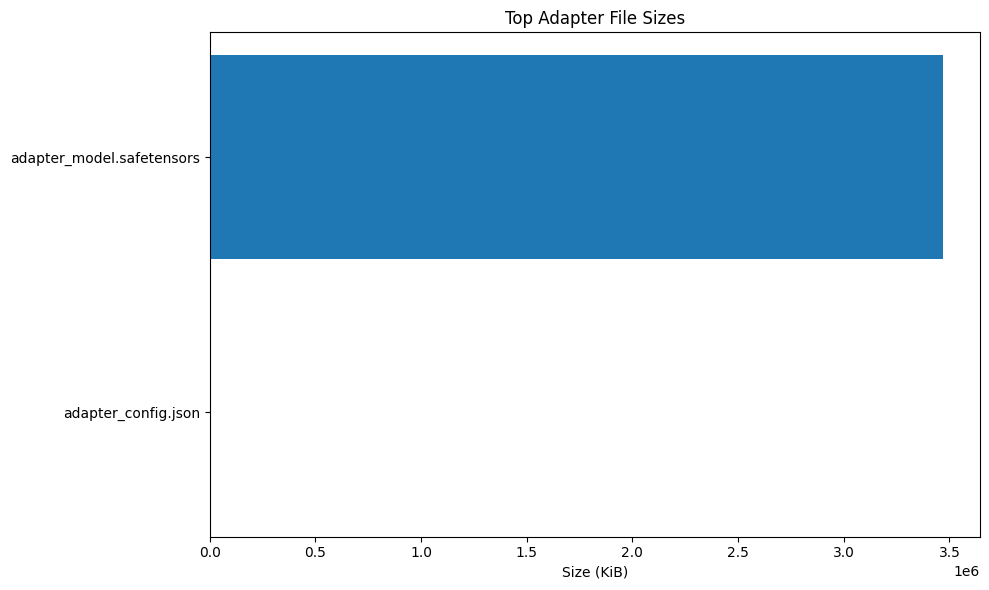

Zip contents sample: ['adapter_config.json', 'adapter_model.safetensors']
 Wrote /kaggle/working/submission.zip (3389.73 MiB)


In [2]:
!uv pip install --no-cache-dir --force-reinstall \
"tinker-cookbook @ git+https://github.com/thinking-machines-lab/tinker-cookbook.git@nightly"


# =========================
# 📥 Download adapter
# =========================
import kagglehub


path = kagglehub.model_download(
    "huikang/nemotron-adapter/transformers/default/20"
)

print("Path to model files:", path)


# =========================
# 📦 Packaging + Visualization
# =========================
import os
import zipfile
from pathlib import Path
import matplotlib.pyplot as plt

MODEL_PATH = Path(
    "/kaggle/input/models/kienngx/nemotron-nano-30b-trained/triton/tinker-adapter/1"
)

OUTPUT_ZIP = Path("/kaggle/working/submission.zip")


def visualize_files(files, model_path):
    names = [p.relative_to(model_path) for p in files]
    sizes = [p.stat().st_size / 1024 for p in files]  # KiB

    top_k = sorted(zip(names, sizes), key=lambda x: x[1], reverse=True)[:15]
    labels = [str(x[0]) for x in top_k]
    values = [x[1] for x in top_k]

    plt.figure(figsize=(10, 6))
    plt.barh(labels, values)
    plt.xlabel("Size (KiB)")
    plt.title("Top Adapter File Sizes")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


def main() -> None:
    if not MODEL_PATH.exists():
        raise FileNotFoundError(f"Adapter path not found: {MODEL_PATH}")

    files = [p for p in MODEL_PATH.rglob("*") if p.is_file()]

    if not files:
        raise RuntimeError(f"No files found under adapter path: {MODEL_PATH}")

    print(f"📦 Packaging {len(files)} files from {MODEL_PATH}")

    # print file stats
    for p in files:
        print(f"- {p.relative_to(MODEL_PATH)} ({p.stat().st_size / 1024:.1f} KiB)")

    # visualization
    visualize_files(files, MODEL_PATH)

    # create zip
    OUTPUT_ZIP.parent.mkdir(parents=True, exist_ok=True)
    if OUTPUT_ZIP.exists():
        OUTPUT_ZIP.unlink()

    with zipfile.ZipFile(OUTPUT_ZIP, "w", compression=zipfile.ZIP_STORED) as zf:
        for p in files:
            zf.write(p, arcname=str(p.relative_to(MODEL_PATH)))

    # verify zip
    with zipfile.ZipFile(OUTPUT_ZIP) as zf:
        names = set(zf.namelist())
        print("Zip contents sample:", list(sorted(names))[:10])

        if "adapter_config.json" not in names:
            raise RuntimeError("submission.zip is missing adapter_config.json at root")

    print(f" Wrote {OUTPUT_ZIP} ({OUTPUT_ZIP.stat().st_size / 1024 / 1024:.2f} MiB)")


if __name__ == "__main__":
    main()